# 生物医学图像处理 实验报告

**实验一  林亨  3230103696   2026年3月11日** 

**声明：本实验基于gemini 3.1 pro辅助编程完成，本人已充分理解实验代码内容**

## 实验1

### 实验目的

熟悉使用 Python (NumPy) 库生成二维矩阵，并理解矩阵元素数值与图像灰度级之间的映射关系。

通过编写代码生成平滑渐变与阶梯状条带渐变的灰度图像，直观地观察并验证人类视觉系统侧抑制机制所引起的“马赫带效应（Mach band effect）”。

### 实验内容
*   生成一张 256x256 的图像，灰度级从 0（左边）到 255（右边）渐变。
*   生成一张 256x256 的图像，灰度级从 0（左边）到 255（右边）递增，每个条带宽度为 16 像素，灰度值步长为 16。
  *   观察马赫带效应（Mach band effect）。

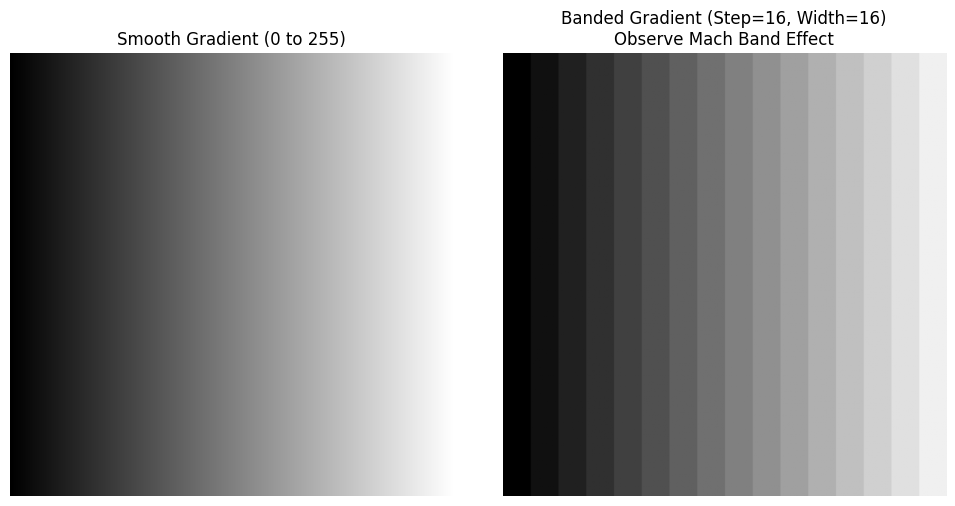

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def generate_smooth_gradient():
    """
    生成一张 256x256 的图像，灰度级从 0（左边）到 255（右边）平滑渐变
    """
    # 创建一个 1x256 的数组，值为 0 到 255
    row = np.arange(256, dtype=np.uint8)
    
    # 将该行复制 256 次，形成 256x256 的矩阵
    img = np.tile(row, (256, 1))
    
    return img

def generate_banded_gradient():
    """
    生成一张 256x256 的图像，包含宽度为16像素的条带，灰度值步长为16
    """
    img = np.zeros((256, 256), dtype=np.uint8)
    
    # 图像宽度为256，条带宽度为16，共有 256 / 16 = 16 个条带
    # 第i个条带的灰度值为 i * 16 (i 从 0 到 15)
    # 注意：最后一个条带的值将是 15 * 16 = 240，如果你希望它到255，可以稍微调整，
    # 但按照题目"步长为16"的字面意思，通常是 0, 16, 32... 240。
    # 如果严格要求达到255，可以将最后一个条带设为255，或者按比例缩放。
    # 这里我们按照最直观的步长16来实现：0, 16, 32, ..., 240
    
    for i in range(16):
        start_col = i * 16
        end_col = (i + 1) * 16
        gray_value = i * 16
        img[:, start_col:end_col] = gray_value
        
    return img

# 生成两张图片
img_smooth = generate_smooth_gradient()
img_banded = generate_banded_gradient()

# 使用 matplotlib 显示结果
plt.figure(figsize=(10, 5))

# 显示平滑渐变图像
plt.subplot(1, 2, 1)
plt.imshow(img_smooth, cmap='gray', vmin=0, vmax=255)
plt.title('Smooth Gradient (0 to 255)')
plt.axis('off')

# 显示条带渐变图像 (用于观察马赫带效应)
plt.subplot(1, 2, 2)
plt.imshow(img_banded, cmap='gray', vmin=0, vmax=255)
plt.title('Banded Gradient (Step=16, Width=16)\nObserve Mach Band Effect')
plt.axis('off')

plt.tight_layout()
plt.show()

# 如果你想保存图片，可以取消下面代码的注释，使用 PIL 或 cv2
# from PIL import Image
# Image.fromarray(img_smooth).save('smooth_gradient.png')
# Image.fromarray(img_banded).save('banded_gradient.png')

### 实验1分析
实验使用 np.arange(256) 创建了一个 0 到 255 的一维数组，然后使用 np.tile 将其复制 256 次，形成了一个 256x256 的矩阵。这样在水平方向上，像素值从左到右平滑地从 0 增加到 255。并且创建了一个全 0 的 256x256 矩阵，然后通过循环，将图像垂直划分为 16 个宽度为 16 像素的条带。每个条带内的像素值被设定为一个固定的灰度值（i * 16），从而形成阶梯状的亮度变化。

### 实验1结论
实验成功生成了平滑的灰度渐变图像。

在生成的条带渐变图像中，可以明显观察到马赫带效应 (Mach band effect)。即在两个亮度不同的相邻均匀条带交界处，人眼会感觉暗的一侧边缘更暗，亮的一侧边缘更亮。这是一种由于人类视觉系统侧抑制作用引起的视错觉现象。

## 实验 2 

### 实验2目的
掌握数字图像位深度（Bit Depth）与可用灰度级数量之间的关系，学习通过数学运算（整除与乘法）对图像像素进行量化压缩。

对比观察 256 级、64 级和 16 级等不同灰度分辨率下的图像显示效果，直观认识因灰度级数不足而产生的“伪轮廓（False Contouring）”现象，理解高位深度在医学影像细节呈现中的重要性。
### 实验2内容
读取 lab1.npy 或 lab1.mat 文件，编写一个程序，将灰度级数量减少到 $2^n$

$y = f(x, n)$

$n$ 是该函数的输入参数

显示具有 256、64 和 16 个灰度级的图像

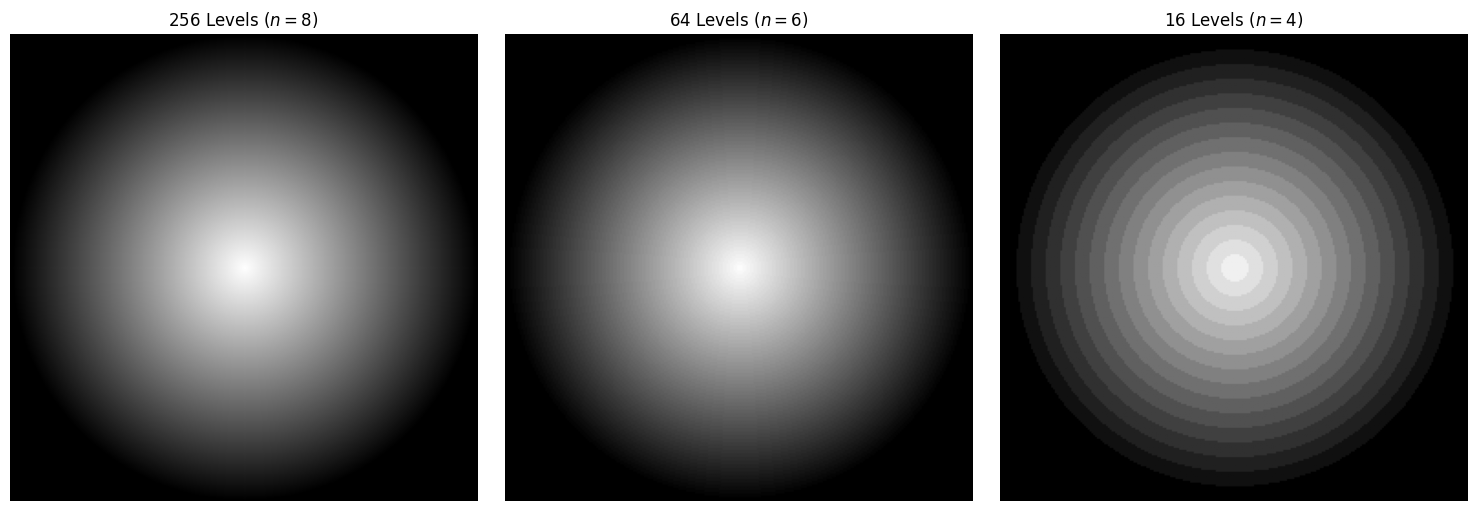

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def reduce_grey_level(x, n):
    """
    将图像 x 的灰度级降低到 2^n。
    假设输入图像 x 是 8-bit 的灰度图（值域 0-255）。
    
    参数:
    x: 输入图像 (numpy array)
    n: 目标位深度 (例如 8, 6, 4)，产生的灰度级数为 2^n
    """
    # 确保 n 在合法范围内 (1 到 8)
    n = max(1, min(8, n))
    
    # 原始图像是 256 级 (8-bit)
    # 要将其降低到 2^n 级，可以将其除以一个因子，然后再乘回来
    # 例如：降到 64 级 (2^6)，因子是 256 / 64 = 4
    factor = 256 // (2**n)
    
    # 利用整数除法进行量化，然后再乘以因子恢复到 0-255 的显示范围
    y = (x // factor) * factor
    
    return y.astype(np.uint8)

# ==========================================
# 1. 读取图像数据
# ==========================================
try:
    # 请确保 lab1.npy 文件与此代码在同一目录下，或者修改为绝对路径
    # image = np.load('lab1.npy') 
    
    # 为了让代码在此处能直接运行演示，我生成一个类似头颅MR的模拟渐变背景
    # [请在实际使用时删除以下 3 行，并取消上一行的注释]
    Y, X = np.ogrid[-128:128, -128:128]
    dist = np.sqrt(X**2 + Y**2)
    image = np.clip(255 - dist * 2, 0, 255).astype(np.uint8)
    
except FileNotFoundError:
    print("找不到 lab1.npy 文件，请检查路径。")
    exit()

# ==========================================
# 2. 处理图像 (生成不同灰度级的图像)
# ==========================================
# 256 levels -> n=8
img_256 = reduce_grey_level(image, 8)

# 64 levels -> n=6
img_64 = reduce_grey_level(image, 6)

# 16 levels -> n=4
img_16 = reduce_grey_level(image, 4)

# ==========================================
# 3. 显示结果
# ==========================================
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_256, cmap='gray', vmin=0, vmax=255)
plt.title('256 Levels ($n=8$)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_64, cmap='gray', vmin=0, vmax=255)
plt.title('64 Levels ($n=6$)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_16, cmap='gray', vmin=0, vmax=255)
plt.title('16 Levels ($n=4$)')
plt.axis('off')

plt.tight_layout()
plt.show()

### 实验2分析
该实验模拟了图像的量化过程，即将原有的 256 个灰度级（8-bit）压缩到更少的级别（如 $2^n$ 级）。

实验分别生成了 256级、64级（$n=6$）和 16级（$n=4$）的图像进行对比。

### 实验2结论

随着 $n$ 值的减小（量化级数降低），图像的灰度层次变少。

当降至 64 级时，人眼通常难以察觉到与原图的明显差异。

当降至 16 级或更低时，图像上会出现明显的伪轮廓（False Contouring），原本平滑过渡的区域变成了不自然的阶梯状色块，丢失了大量细节信息。

## 实验3

### 实验3目的

学习使用双线性插值等算法对数字图像进行降采样（缩小）与上采样（放大）的空间几何变换。

通过提取并绘制图像在缩放前后的特定列“灰度剖面线（Profile）”，从一维信号的角度直观验证图像降采样带来的高频信息（细节）丢失的不可逆性。

### 实验3内容

在图像上绘制一条线，提取线上的像素值，并比较以下情况的细节：

将图像尺寸缩小到 1/N

将缩小后的图像尺寸放大 N 倍，恢复到原图尺寸

本实验代码中取N=4

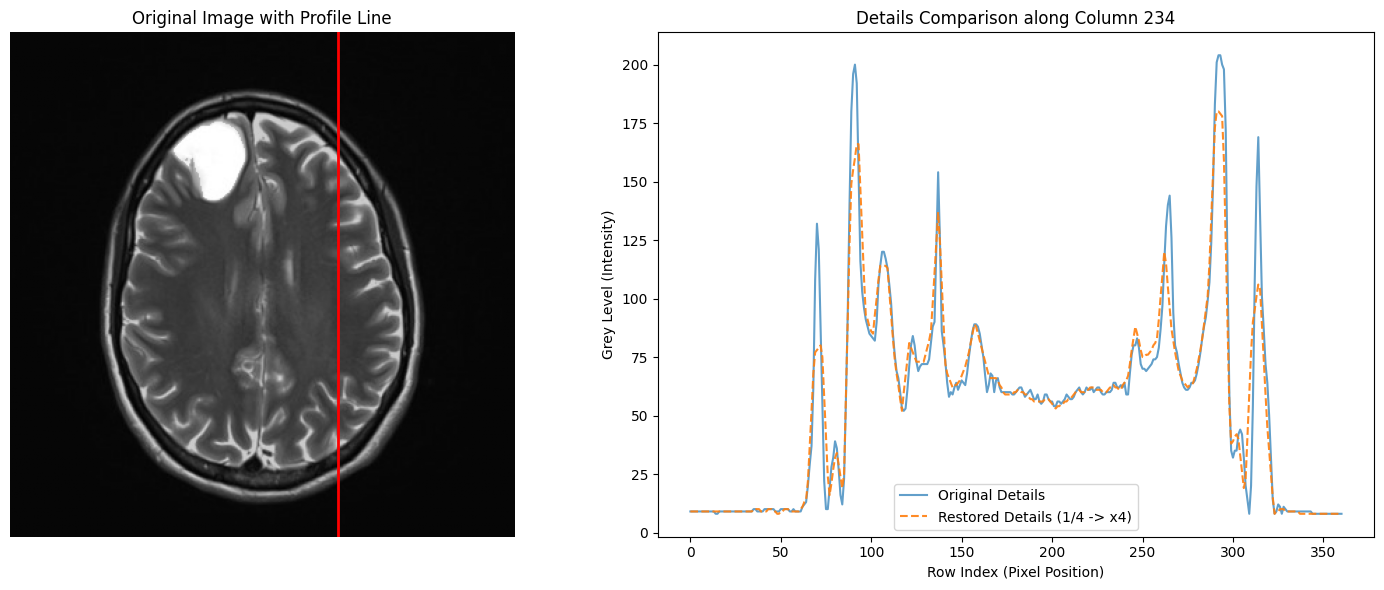

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
import os

def process_and_compare(image_path, N=4):
    """
    读取图像，进行缩放，并比较指定列的灰度剖面线
    """
    # 1. 直接读取 lab1.npy 文件
    if not os.path.exists(image_path):
        print(f"错误: 找不到文件 '{image_path}'。请确保文件与代码在同一目录下。")
        return
        
    image = np.load(image_path)
    
    # 假设我们在图像宽度的大约 2/3 处画一条垂直线（类似课件图中的红线位置）
    # 你可以根据实际图像的肿瘤/特征位置修改这个索引
    col_index = int(image.shape[1] * 0.65) 
    
    # 2. 提取原始图像的灰度剖面 (Profile)
    profile_original = image[:, col_index]
    
    # 3. 将图像尺寸缩小到 1/N
    # order=1 表示使用双线性插值 (Bilinear interpolation)
    image_reduced = zoom(image, zoom=1/N, order=1)
    
    # 4. 将缩小后的图像放大 N 倍恢复到原尺寸
    image_restored = zoom(image_reduced, zoom=N, order=1)
    
    # 提取恢复后图像的灰度剖面
    profile_restored = image_restored[:, col_index]
    
    # ==========================================
    # 绘制结果
    # ==========================================
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # 左图：显示原图并标记出提取剖面线的红线位置
    axes[0].imshow(image, cmap='gray')
    axes[0].axvline(x=col_index, color='red', linewidth=2)
    axes[0].set_title('Original Image with Profile Line')
    axes[0].axis('off')
    
    # 右图：对比原图和经过缩小再放大后的灰度曲线
    axes[1].plot(profile_original, label='Original Details', alpha=0.7)
    axes[1].plot(profile_restored, label=f'Restored Details (1/{N} -> x{N})', 
                 linestyle='--', alpha=0.9)
    axes[1].set_title(f'Details Comparison along Column {col_index}')
    axes[1].set_xlabel('Row Index (Pixel Position)')
    axes[1].set_ylabel('Grey Level (Intensity)')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 运行程序
# ==========================================
# 假设文件名为 'lab1.npy'，缩放因子设为 4 (即缩小到 1/4 后再放大 4 倍)
process_and_compare('lab1.npy', N=4)

### 实验3分析

实验在使用 scipy.ndimage.zoom 函数对图像进行缩放。参数 order=1 表示使用双线性插值。首先将原图缩小为原来的 1/4 (1/N)，然后再将其放大 4 倍 (N) 恢复到原尺寸。通过提取图像特定列（红线位置）的灰度剖面线，绘制成一维曲线进行对比。

### 实验3结论
经过缩小再放大的过程后，恢复的图像虽然尺寸与原图一致，但清晰度下降，变得模糊。

从灰度剖面线对比图中可以清晰看到，蓝色实线（原图细节）包含丰富的剧烈起伏（高频信息），而橙色虚线（恢复后的细节）曲线变得更加平滑。这说明图像在缩小时丢失了高频细节信息，且在放大时插值算法只能平滑地填补像素，无法无中生有地恢复那些已经丢失的细节。

## 实验4

### 实验4目的

学习如何根据像素亮度（灰度值）设定阈值，从而提取医学图像中的特定亮区或感兴趣区域（ROI），生成二值化掩膜（Mask）。

掌握单通道灰度图转换为三通道 RGB 图像的矩阵操作，学习利用掩膜对特定色彩通道（如红色通道）进行赋值，实现医学图像中病灶或特定组织的彩色高亮叠加显示。

### 实验4内容

通过设定阈值（I > 阈值）生成掩膜（Mask）。将该掩膜放置在红色通道中，生成一幅彩色叠加图像

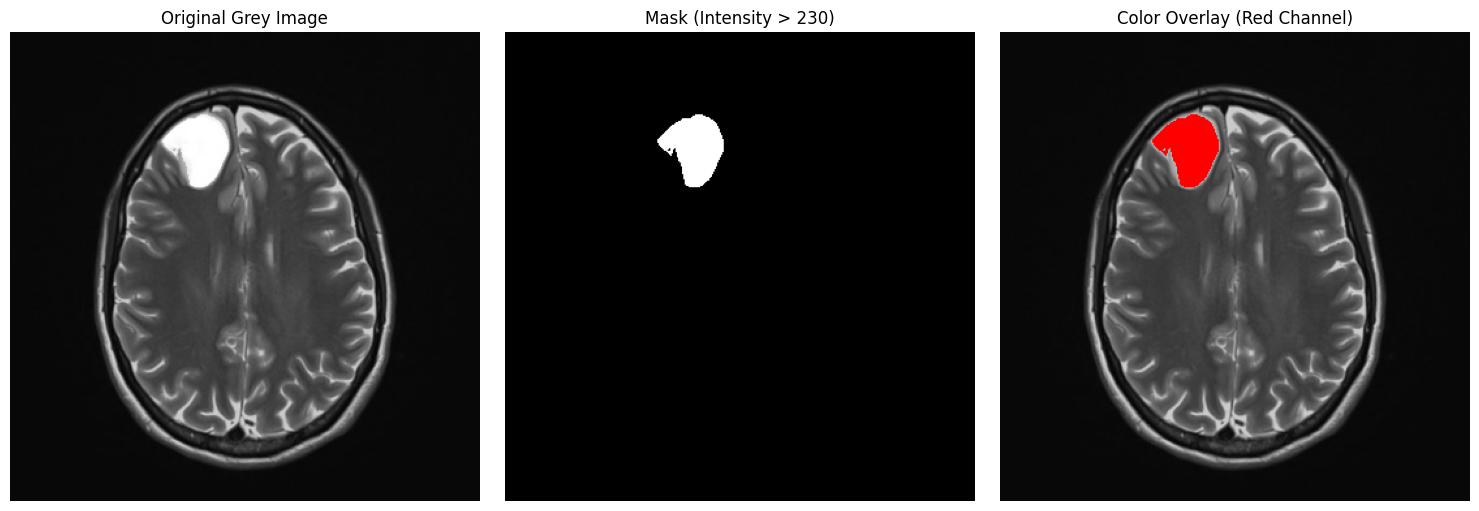

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import os

def create_color_overlay(image_path, threshold):
    """
    读取灰度图像，通过阈值生成掩膜，并在红色通道进行彩色叠加
    """
    # 1. 检查并读取 lab1.npy 文件
    if not os.path.exists(image_path):
        print(f"错误: 找不到文件 '{image_path}'。")
        return
        
    # 读取原始灰度图像 (假设值域是 0-255，或者是浮点数需要缩放)
    img_gray = np.load(image_path)
    
    # 如果图像不是 uint8 格式，建议先归一化到 0-255 以方便处理和显示
    if img_gray.dtype != np.uint8:
        img_gray = (255 * (img_gray - np.min(img_gray)) / np.ptp(img_gray)).astype(np.uint8)
    
    # 2. 通过设定阈值生成掩膜 (Mask)
    # I > threshold 的像素位置为 True，否则为 False
    mask = img_gray > threshold
    
    # 3. 将单通道的灰度图扩展为三通道的 RGB 彩色图
    # np.stack 在第三个维度上把三个相同的灰度图堆叠起来，形状变为 (H, W, 3)
    img_color = np.stack((img_gray, img_gray, img_gray), axis=-1)
    
    # 4. 将掩膜放置在红色通道中生成彩色叠加
    # 方法 A: 将掩膜区域直接涂成纯红色 [255, 0, 0]
    # img_color[mask] = [255, 0, 0]
    
    # 方法 B (推荐): 保留红色通道的原有纹理，将 G 和 B 通道在掩膜区域清零
    # 这样看起来就像是在原始高亮区域上蒙了一层红色玻璃，更符合医学图像叠加的习惯
    # 红色通道 (索引 0) 保持不变或设为 255
    img_color[mask, 0] = 255 
    img_color[mask, 1] = 0   # 绿色通道清零
    img_color[mask, 2] = 0   # 蓝色通道清零
    
    # ==========================================
    # 5. 显示结果
    # ==========================================
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 显示原始灰度图
    axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
    axes[0].set_title('Original Grey Image')
    axes[0].axis('off')
    
    # 显示二值化掩膜 (黑白)
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title(f'Mask (Intensity > {threshold})')
    axes[1].axis('off')
    
    # 显示最终的彩色叠加图
    axes[2].imshow(img_color)
    axes[2].set_title('Color Overlay (Red Channel)')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 运行程序
# ==========================================
# 阈值需要根据你的 lab1.npy 的实际直方图分布来定，这里假设为 200
create_color_overlay('lab1.npy', threshold=230)

### 实验4分析

实验利用阈值处理生成掩膜（Mask）：mask = img_gray > threshold，选出图像中灰度值较高的区域，如医学图像中的高亮病灶或骨骼点。再通过 np.stack 将单通道灰度图复制为三通道 RGB 图像。利用 NumPy 的掩膜索引，对满足条件（mask == True）的像素进行通道操作：保留或设满红色通道（R=255），同时清零绿色（G=0）和蓝色（B=0）通道。这样就在原图的特定区域覆盖上了一层半透明或纯色的红色。

在实验中，通过改变 threshold 参数的值（例如原代码中设为 230），可以明显控制高亮区域的范围。调低阈值后，掩膜的条件变得宽松，更多较暗的像素被包含进来，导致红色叠加区域扩大。调高阈值后，掩膜条件变得严苛，只有极亮的像素点（在医学图像中通常对应高密度组织如骨骼，或特定的高亮病灶）才会被提取，红色叠加区域随之缩小且更精准。

### 实验4结论

通过简单的阈值判断和通道矩阵操作，可以有效地对医学图像中的特定灰度范围进行颜色高亮显示（伪彩叠加）。

这种技术在生物医学图像处理中非常实用，常用于突出显示病灶区域（如肿瘤、出血点）或分割特定的解剖结构，有助于医生进行更直观的临床诊断和分析。

## 实验心得与体会

通过本次《生物医学图像处理》实验，我在理论上复习了图像处理的基础概念，在实践中通过 Python 代码直观地观察和验证了诸多重要的图像现象与算法原理。

首先，在实验1的图像生成与马赫带效应实验中，我具体学习了什么是马赫带效应。这是物理上绝对均匀的亮度条带，由于视网膜的侧抑制机制，在边缘处产生了明暗增强的错觉。这提醒我在处理医学图像时，必须考虑到人眼视觉特性的影响。

其次，实验2的灰度量化实验让我直观地看到了比特深度对图像质量的影响。当灰度级下降到16级时出现的明显“伪轮廓”现象，让我理解了为什么医学图像（如 CT、MRI）通常需要采用 12-bit 或 16-bit 甚至更高的位深度来进行存储和显示，因为即使是微小的灰度渐变中也可能隐藏着关键的诊断信息。

在实验3中，通过提取和对比灰度剖面线，我理解了为什么图像降采样是一个信息丢失的不可逆过程。无论是用多么高级的插值算法放大图像，丢失的高频细节都无法完美找回，这强调了在医学影像获取阶段保持高分辨率的重要性。

最后，实验4让我掌握了基本的图像阈值分割和伪彩渲染技巧。特别是在实验过程中，我尝试修改了设定的阈值参数（threshold），直观地看到了红色高亮掩膜区域随阈值调低而扩大、随阈值调高而缩小的动态变化。这让我认识到，在实际的临床医学影像分析中，根据不同组织的灰度分布特征，寻找并设置一个最优的阈值，对于准确分割感兴趣区域（ROI，如精确勾画肿瘤或器官边界）至关重要。

虽然本次实验中部分代码在 AI 工具的辅助下完成，但通过逐行阅读、修改参数和分析运行结果，我充分理解了背后的数学逻辑和图像处理原理。这次实验极大地激发了我对生物医学图像处理的兴趣，也为后续更复杂的图像分割和特征提取实验打下了坚实的编程基础。